In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving dim_date.csv to dim_date.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dim_hotels.csv to dim_hotels.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dim_rooms.csv to dim_rooms.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fact_aggregated_bookings.csv to fact_aggregated_bookings.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving new_data_august.csv to new_data_august.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fact_bookings.csv to fact_bookings.csv


In [ ]:
df_date = pd.read_csv("dim_date.csv")
df_hotels = pd.read_csv("dim_hotels.csv")
df_rooms = pd.read_csv("dim_rooms.csv")
df_bookings = pd.read_csv("fact_bookings.csv")
df_agg_bookings = pd.read_csv("fact_aggregated_bookings.csv")
df_aug = pd.read_csv("new_data_august.csv")

# **Data Exploration**

In [ ]:
df_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [ ]:
df_hotels["property_name"].unique()

array(['Atliq Grands', 'Atliq Exotica', 'Atliq City', 'Atliq Blu',
       'Atliq Bay', 'Atliq Palace', 'Atliq Seasons'], dtype=object)

In [ ]:
df_hotels["city"].unique()

array(['Delhi', 'Mumbai', 'Hyderabad', 'Bangalore'], dtype=object)

In [ ]:
df_hotels["category"].unique()

array(['Luxury', 'Business'], dtype=object)

In [ ]:
df_hotels.groupby("city")["category"].count()

,category
city,
Bangalore,6
Delhi,5
Hyderabad,6
Mumbai,8


In [ ]:
df_hotels.groupby("city")["category"].apply(list)

,category
city,
Bangalore,"[Luxury, Luxury, Business, Luxury, Luxury, Bus..."
Delhi,"[Luxury, Business, Luxury, Luxury, Business]"
Hyderabad,"[Luxury, Luxury, Business, Luxury, Luxury, Bus..."
Mumbai,"[Luxury, Luxury, Luxury, Business, Luxury, Lux..."


# Distribution of Hotels Across Categories

In [ ]:
df_hotels.category.value_counts()

,count
category,
Luxury,16
Business,9


# Distribution of Hotels Across Cities

In [ ]:
df_hotels.city.value_counts()

,count
city,
Mumbai,8
Hyderabad,6
Bangalore,6
Delhi,5


# City-wise Hotel Distribution (Bar Chart)

<Axes: xlabel='city'>

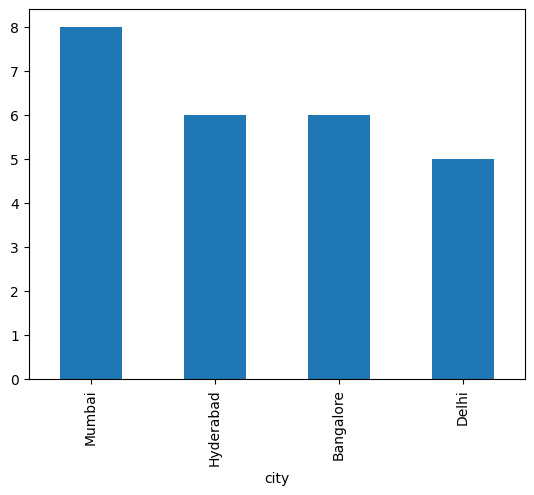

In [ ]:
df_hotels.city.value_counts().sort_values(ascending=False).plot(kind = 'bar')

In [ ]:
df_bookings.shape

(134590, 12)

In [ ]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [ ]:
df_bookings.room_category.unique()

array(['RT1', 'RT2', 'RT3', 'RT4'], dtype=object)

In [ ]:
df_bookings.booking_platform.unique()

array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

# Distribution of Bookings Across Platforms

In [ ]:
df_bookings['booking_platform'].value_counts().sort_values(ascending =False).reset_index()

,booking_platform,count
0,others,55066
1,makeyourtrip,26898
2,logtrip,14756
3,direct online,13379
4,tripster,9630
5,journey,8106
6,direct offline,6755


<Axes: xlabel='booking_platform'>

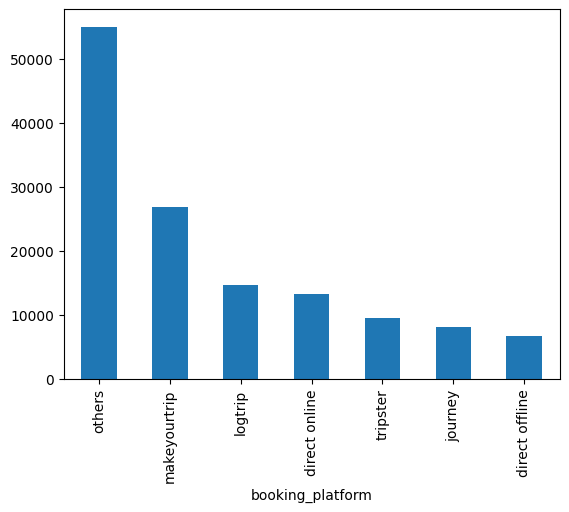

In [ ]:
df_bookings.booking_platform.value_counts().plot(kind='bar')

In [ ]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


# Property-wise Booking Analysis

In [ ]:
df_agg_bookings.groupby("property_id")["successful_bookings"].sum().reset_index()

,property_id,successful_bookings
0,16558,3153
1,16559,7338
2,16560,4693
3,16561,4418
4,16562,4820
5,16563,7211
6,17558,5053
7,17559,6142
8,17560,6013
9,17561,5183


# Days with Bookings Exceeding Capacity

In [ ]:
df_agg_bookings[
    df_agg_bookings["successful_bookings"] > df_agg_bookings["capacity"]
][["check_in_date","successful_bookings",	"capacity"]]

,check_in_date,successful_bookings,capacity
3,1-May-22,30,19.0
12,1-May-22,100,41.0
4136,11-Jun-22,50,39.0
6209,2-Jul-22,123,26.0
8522,25-Jul-22,35,24.0
9194,31-Jul-22,20,18.0


# Properties with Highest Capacity

In [ ]:
df_agg_bookings.groupby("property_id")["capacity"].sum().sort_values(ascending=False).reset_index()

,property_id,capacity
0,18559,11776.0
1,17560,11316.0
2,16559,11132.0
3,18562,11132.0
4,16563,10764.0
5,19561,10764.0
6,19563,10120.0
7,18560,10028.0
8,19558,9844.0
9,18561,9844.0


# **Data Cleaning**

In [ ]:
df_bookings.shape

(134590, 12)

In [ ]:
# here min no_of_guests = -17 which looks like an error
# In revenue_generated max revenue for 1 day or per_booking is 2.8 crore which also seems an error
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


# Identifying Rows with Negative Guest Count

In [ ]:
df_bookings[df_bookings['no_guests']<=0].reset_index()


,index,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city


# Data Cleaning: Removing Invalid no_guests Records

In [ ]:
df_bookings = df_bookings[df_bookings['no_guests']>=0]
df_bookings.shape

(134578, 12)

In [ ]:
# In revenue_generated max revenue for 1 day or per_booking is 2.8 crore which also seems an error
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(6500, 28560000)

In [ ]:
# max_value = 28560000 looks like an outlier so lets remove outlier by  3 std_deviations
# lets find Mean and std
mean , std = df_bookings.revenue_generated.mean() , df_bookings.revenue_generated.std()
mean ,std


(np.float64(15378.036937686695), 93040.15493143328)

In [ ]:
# finding 3 std
higher_limit = round(mean + 3*std,2)
higher_limit

np.float64(294498.5)

# Identifying High Revenue Outliers Using 3 Standard Deviations

In [ ]:
df_bookings[df_bookings['revenue_generated'] > higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [ ]:
# Filtering Out Revenue Outliers
df_bookings = df_bookings[df_bookings['revenue_generated'] <= higher_limit]
df_bookings.shape

(134573, 12)

In [ ]:
# ratings_given has many null values since most users don’t provide ratings. This is expected, so no null handling is needed for this column.
print(df_bookings.isnull().sum())

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64


# Data Quality Check: Identifying Missing Values

In [ ]:
df_agg_bookings.isna().sum()

,0
property_id,0
check_in_date,0
room_category,0
successful_bookings,0
capacity,2


In [ ]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


# Replacing NA values with Mean values

In [ ]:
df_agg_bookings['capacity'] = df_agg_bookings["capacity"].fillna(df_agg_bookings["capacity"].mean())

In [ ]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


# Analyzing Records with Excess Booking Demand

In [ ]:
df_bigger_succ_bookings = df_agg_bookings[df_agg_bookings["successful_bookings"]> df_agg_bookings['capacity']].reset_index()
df_bigger_succ_bookings

,index,property_id,check_in_date,room_category,successful_bookings,capacity
0,3,17558,1-May-22,RT1,30,19.0
1,12,16563,1-May-22,RT1,100,41.0
2,4136,19558,11-Jun-22,RT2,50,39.0
3,6209,19560,2-Jul-22,RT1,123,26.0
4,8522,19559,25-Jul-22,RT1,35,24.0
5,9194,18563,31-Jul-22,RT4,20,18.0


# **Data Transformation**

#   Calculating occupancy_%

In [ ]:
df_agg_bookings["occ%"] = round(df_agg_bookings["successful_bookings"]*100/df_agg_bookings["capacity"],2)
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ%
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
3,17558,1-May-22,RT1,30,19.0,157.89
4,16558,1-May-22,RT1,18,19.0,94.74


# Analyzing Properties with Maximum Capacity

In [ ]:
df_high_cap = df_agg_bookings.groupby("property_id")["capacity"].sum().sort_values(ascending=False).reset_index()
df_final = df_high_cap[df_high_cap["capacity"] == df_high_cap["capacity"].max()]
result = df_final.merge(df_hotels[["property_id","property_name"]],on = "property_id")[['property_name','capacity']]
result

,property_name,capacity
0,Atliq Exotica,11776.0


# Analyzing Overbooking Scenarios in Booking Data

In [ ]:
df_bigger_succ_booking = df_agg_bookings[df_agg_bookings["successful_bookings"]> df_agg_bookings['capacity']].reset_index()
df_bigger_succ_booking.drop("index",axis=1,inplace=True)
df_bigger_succ_booking

,index,property_id,check_in_date,room_category,successful_bookings,capacity,occ%
0,3,17558,1-May-22,RT1,30,19.0,157.89
1,12,16563,1-May-22,RT1,100,41.0,243.90
2,4136,19558,11-Jun-22,RT2,50,39.0,128.21
3,6209,19560,2-Jul-22,RT1,123,26.0,473.08
4,8522,19559,25-Jul-22,RT1,35,24.0,145.83
5,9194,18563,31-Jul-22,RT4,20,18.0,111.11


# **Insights Generation**

# Analyzing Average Occupancy Rate Across Hotel Categories

In [ ]:
avg_occ_rate = df_agg_bookings.groupby("room_category", as_index = False)['occ%'].mean()
avg_occ_rate

,room_category,occ%
0,RT1,58.232091
1,RT2,58.040278
2,RT3,58.028213
3,RT4,59.300461


In [ ]:
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [ ]:
df = pd.merge(df_agg_bookings,df_rooms[["room_id","room_class"]], left_on = 'room_category',right_on = 'room_id')[["property_id",	"check_in_date",	"room_category","room_class",	"successful_bookings",	"capacity",	"occ%"	]]
df.head()

,property_id,check_in_date,room_category,room_class,successful_bookings,capacity,occ%
0,16559,1-May-22,RT1,Standard,25,30.0,83.33
1,19562,1-May-22,RT1,Standard,28,30.0,93.33
2,19563,1-May-22,RT1,Standard,23,30.0,76.67
3,17558,1-May-22,RT1,Standard,30,19.0,157.89
4,16558,1-May-22,RT1,Standard,18,19.0,94.74


In [ ]:
avg_occ_rate = df.groupby(["room_category","room_class"])['occ%'].mean().reset_index()
avg_occ_rate

,room_category,room_class,occ%
0,RT1,Standard,58.232091
1,RT2,Elite,58.040278
2,RT3,Premium,58.028213
3,RT4,Presidential,59.300461


#Analyzing Average Occupancy Rate Across Cities

In [ ]:
df_hotels.head(2)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai


In [ ]:
df = pd.merge(df,df_hotels[["property_id","property_name","category","city"]],on="property_id")
df.head()

,property_id,check_in_date,room_category,room_class,successful_bookings,capacity,occ%,property_name,category,property_name,category,city
0,16559,1-May-22,RT1,Standard,25,30.0,83.33,Atliq Exotica,Luxury,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,Standard,28,30.0,93.33,Atliq Bay,Luxury,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,RT1,Standard,23,30.0,76.67,Atliq Palace,Business,Atliq Palace,Business,Bangalore
3,17558,1-May-22,RT1,Standard,30,19.0,157.89,Atliq Grands,Luxury,Atliq Grands,Luxury,Mumbai
4,16558,1-May-22,RT1,Standard,18,19.0,94.74,Atliq Grands,Luxury,Atliq Grands,Luxury,Delhi


In [ ]:
avg_occ_per_city = df.groupby("city",as_index=False)['occ%'].mean()
avg_occ_per_city

,city,occ%
0,Bangalore,56.594207
1,Delhi,61.606467
2,Hyderabad,58.144651
3,Mumbai,57.942629


# Weekday vs Weekend Occupancy Performance Comparison


In [ ]:
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df_date["date"] = pd.to_datetime(df_date["date"])

/tmp/ipykernel_4371/628280166.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_date["date"] = pd.to_datetime(df_date["date"])


In [ ]:
df = pd.merge(df,df_date,left_on="check_in_date",right_on  = "date")
df.head()

,property_id,check_in_date,room_category,room_class,successful_bookings,capacity,occ%,property_name,category,city,date,mmm yy,week no,day_type
0,16559,2022-05-01,RT1,Standard,25,30.0,83.33,Atliq Exotica,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend
1,19562,2022-05-01,RT1,Standard,28,30.0,93.33,Atliq Bay,Luxury,Bangalore,2022-05-01,May 22,W 19,weekend
2,19563,2022-05-01,RT1,Standard,23,30.0,76.67,Atliq Palace,Business,Bangalore,2022-05-01,May 22,W 19,weekend
3,17558,2022-05-01,RT1,Standard,30,19.0,157.89,Atliq Grands,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend
4,16558,2022-05-01,RT1,Standard,18,19.0,94.74,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend


In [ ]:
high_occ = df.groupby("day_type",as_index=False)["occ%"].mean().round(2)
high_occ

,day_type,occ%
0,weekeday,51.82
1,weekend,74.24


# Weekday vs Weekend Occupancy (Bar Chart)

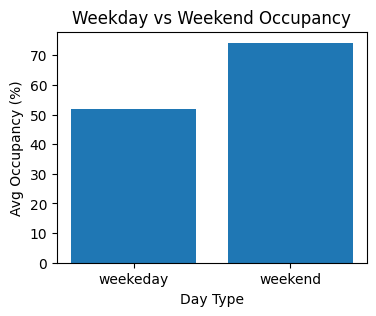

In [ ]:
import matplotlib.pyplot as plt

high_occ = df.groupby("day_type", as_index=False)["occ%"].mean().round(2)

plt.figure(figsize=(4,3))
plt.bar(high_occ['day_type'], high_occ['occ%'])

plt.xlabel("Day Type")
plt.ylabel("Avg Occupancy (%)")
plt.title("Weekday vs Weekend Occupancy")

plt.show()

# City-wise Occupancy in June


In [ ]:
df.sample(5)

,property_id,check_in_date,room_category,room_class,successful_bookings,capacity,occ%,property_name,category,city,date,mmm yy,week no,day_type
9008,19560,2022-07-30,RT1,Standard,22,26.0,84.62,Atliq City,Business,Bangalore,2022-07-30,Jul 22,W 31,weekend
363,16561,2022-05-04,RT3,Premium,14,21.0,66.67,Atliq Blu,Luxury,Delhi,2022-05-04,May 22,W 19,weekeday
5460,17559,2022-06-24,RT3,Premium,8,16.0,50.00,Atliq Exotica,Luxury,Mumbai,2022-06-24,Jun 22,W 26,weekeday
5352,19561,2022-06-23,RT3,Premium,12,29.0,41.38,Atliq Blu,Luxury,Bangalore,2022-06-23,Jun 22,W 26,weekeday
6291,19562,2022-07-02,RT4,Presidential,13,14.0,92.86,Atliq Bay,Luxury,Bangalore,2022-07-02,Jul 22,W 27,weekend


In [ ]:
df_june_22= df[df["mmm yy"] == "Jun 22"]


In [ ]:
june_occu = ( df_june_22.groupby("city")["occ%"].mean().round(2).sort_values(ascending=False)).reset_index()
june_occu

,city,occ%
0,Delhi,61.46
1,Mumbai,57.79
2,Hyderabad,57.69
3,Bangalore,55.95


# Appending August Data to the Dataset

In [ ]:
df.columns

Index(['property_id', 'check_in_date', 'room_category', 'room_class',
       'successful_bookings', 'capacity', 'occ%', 'property_name', 'category',
       'city', 'date', 'mmm yy', 'week no', 'day_type'],
      dtype='object')

In [ ]:
df_aug.columns

Index(['property_id', 'property_name', 'category', 'city', 'room_category',
       'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type',
       'successful_bookings', 'capacity', 'occ%'],
      dtype='object')

In [ ]:
latest_df = pd.concat([df,df_aug],ignore_index=True,axis=0)

In [ ]:
latest_df

,property_id,check_in_date,room_category,room_class,successful_bookings,capacity,occ%,property_name,category,city,date,mmm yy,week no,day_type
0,16559,2022-05-01 00:00:00,RT1,Standard,25,30.0,83.33,Atliq Exotica,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend
1,19562,2022-05-01 00:00:00,RT1,Standard,28,30.0,93.33,Atliq Bay,Luxury,Bangalore,2022-05-01,May 22,W 19,weekend
2,19563,2022-05-01 00:00:00,RT1,Standard,23,30.0,76.67,Atliq Palace,Business,Bangalore,2022-05-01,May 22,W 19,weekend
3,17558,2022-05-01 00:00:00,RT1,Standard,30,19.0,157.89,Atliq Grands,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend
4,16558,2022-05-01 00:00:00,RT1,Standard,18,19.0,94.74,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9202,19563,01-Aug-22,RT1,Standard,23,30.0,76.67,Atliq Palace,Business,Bangalore,NaT,Aug-22,W 32,weekeday
9203,19558,01-Aug-22,RT1,Standard,30,40.0,75.00,Atliq Grands,Luxury,Bangalore,NaT,Aug-22,W 32,weekeday
9204,19560,01-Aug-22,RT1,Standard,20,26.0,76.92,Atliq City,Business,Bangalore,NaT,Aug-22,W 32,weekeday
9205,17561,01-Aug-22,RT1,Standard,18,26.0,69.23,Atliq Blu,Luxury,Mumbai,NaT,Aug-22,W 32,weekeday


# Revenue Realized per City

In [ ]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100


In [ ]:
df_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [ ]:
# revenue_realized column is in df_booking and  city information  data is in hotel table so join/merge df_bookings and df_hotels
df_bookings = pd.merge(df_bookings,df_hotels, on ="property_id")
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi


In [ ]:
revenue_realized_per_city = df_bookings.groupby("city")["revenue_realized"].sum().sort_values(ascending = False)
revenue_realized_per_city

,revenue_realized
city,
Mumbai,668569251
Bangalore,420383550
Hyderabad,325179310
Delhi,294404488


In [ ]:
print(df_bookings.columns.to_list())

['booking_id', 'property_id', 'booking_date', 'check_in_date', 'checkout_date', 'no_guests', 'room_category', 'booking_platform', 'ratings_given', 'booking_status', 'revenue_generated', 'revenue_realized', 'property_name', 'category', 'city']


# Month wise revenue

In [ ]:
# revnue is in df_booking Dataset
df_bookings.head(2)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi


In [ ]:
# Month is in df_date Dataset
df_date.head()

,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday
3,2022-05-04,May 22,W 19,weekeday
4,2022-05-05,May 22,W 19,weekeday


In [ ]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134573 entries, 0 to 134572
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134573 non-null  object 
 1   property_id        134573 non-null  int64  
 2   booking_date       134573 non-null  object 
 3   check_in_date      134573 non-null  object 
 4   checkout_date      134573 non-null  object 
 5   no_guests          134573 non-null  float64
 6   room_category      134573 non-null  object 
 7   booking_platform   134573 non-null  object 
 8   ratings_given      56676 non-null   float64
 9   booking_status     134573 non-null  object 
 10  revenue_generated  134573 non-null  int64  
 11  revenue_realized   134573 non-null  int64  
 12  property_name      134573 non-null  object 
 13  category           134573 non-null  object 
 14  city               134573 non-null  object 
dtypes: float64(2), int64(3), object(10)
memory usage: 1

In [ ]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      92 non-null     datetime64[ns]
 1   mmm yy    92 non-null     object        
 2   week no   92 non-null     object        
 3   day_type  92 non-null     object        
dtypes: datetime64[ns](1), object(3)
memory usage: 3.0+ KB


In [ ]:
# changing df_bookings['check_in_date'] column from object to datetime and since check_in_date column have mixed formats so we have to aapply this code into it
df_bookings['check_in_date'] = pd.to_datetime(
    df_bookings['check_in_date'],
    format='mixed',
    dayfirst=True)

In [ ]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134573 entries, 0 to 134572
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   booking_id         134573 non-null  object        
 1   property_id        134573 non-null  int64         
 2   booking_date       134573 non-null  object        
 3   check_in_date      134573 non-null  datetime64[ns]
 4   checkout_date      134573 non-null  object        
 5   no_guests          134573 non-null  float64       
 6   room_category      134573 non-null  object        
 7   booking_platform   134573 non-null  object        
 8   ratings_given      56676 non-null   float64       
 9   booking_status     134573 non-null  object        
 10  revenue_generated  134573 non-null  int64         
 11  revenue_realized   134573 non-null  int64         
 12  property_name      134573 non-null  object        
 13  category           134573 non-null  object  

In [ ]:
# now its format has changed and become uniform
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134568,Jul312217564RT45,17564,30-07-22,2022-07-31,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai
134569,Jul312217564RT46,17564,29-07-22,2022-07-31,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai
134570,Jul312217564RT48,17564,30-07-22,2022-07-31,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920,Atliq Seasons,Business,Mumbai
134571,Jul312217564RT49,17564,29-07-22,2022-07-31,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai


In [ ]:
# merging df_date columns into df_bookings
df_boking_dates_month = pd.merge(df_bookings,df_date,left_on = "check_in_date", right_on = "date",how = "left")

In [ ]:
month_wise_revenue = df_boking_dates_month.groupby('mmm yy')["revenue_generated"].sum().sort_values(ascending=False).reset_index()
month_wise_revenue

,mmm yy,revenue_generated
0,May 22,683693155
1,Jul 22,671659265
2,Jun 22,651933035


# Analyzing Monthly Revenue Trends

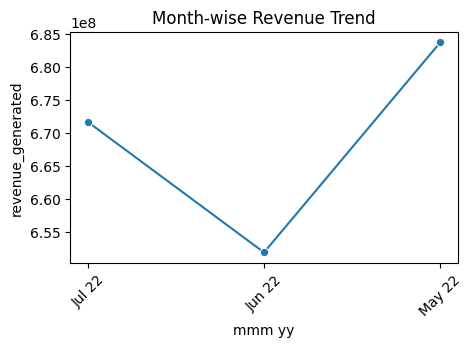

In [ ]:
plt.figure(figsize=(5,3))
sns.lineplot(x='mmm yy', y='revenue_generated', data=month_wise_revenue, marker='o')

plt.xticks(rotation=45)
plt.title("Month-wise Revenue Trend")
plt.show()